# Bài tập 01: PCA & PCA + SVD

Triển khai thuật toán PCA bằng Ma trận hiệp biến (Q1) và SVD (Q2) trên dữ liệu 2D gồm $N = 4$ mẫu:
$$X = \begin{bmatrix} 2 & 3 & 5 & 6 \\ 1 & 5 & 4 & 6 \end{bmatrix}$$


## Q1: Standard PCA via Covariance Matrix


### Bước 1: Khai báo dữ liệu gốc $X \in \mathbb{R}^{2 \times 4}$


In [18]:
import numpy as np

# Nhập ma trận dữ liệu X (2x4)
X = np.array([[2, 3, 5, 6],
              [1, 5, 4, 6]], dtype=float)
print("Ma trận dữ liệu ban đầu X:")
print(X)
print("Kích thước:", X.shape)


Ma trận dữ liệu ban đầu X:
[[2. 3. 5. 6.]
 [1. 5. 4. 6.]]
Kích thước: (2, 4)


### Bước 2: Tính vector trung bình $\mu \in \mathbb{R}^2$
$$\mu = \frac{1}{N} \sum_{i=1}^N x_i$$


In [19]:
# Tính vector trung bình theo hàng (axis=1)
mu = np.mean(X, axis=1, keepdims=True)
print("Vector trung bình mu:")
print(mu)


Vector trung bình mu:
[[4.]
 [4.]]


### Bước 3: Trung tâm hóa dữ liệu $\bar{X} = X - \mu$


In [20]:
# Trung tâm hóa dữ liệu
X_bar = X - mu
print("Ma trận dữ liệu đã trung tâm hóa X_bar:")
print(X_bar)


Ma trận dữ liệu đã trung tâm hóa X_bar:
[[-2. -1.  1.  2.]
 [-3.  1.  0.  2.]]


### Bước 4: Tính Covariance Matrix


In [21]:
# Số lượng mẫu N
N = X.shape[1]

# Tính Covariance Matrix
Sigma = np.cov(X)
print("Covariance Matrix Sigma:")
print(Sigma)


Covariance Matrix Sigma:
[[3.33333333 3.        ]
 [3.         4.66666667]]


### Bước 5: Tính các trị riêng $\lambda_i$ và vector riêng $v_i$ của $\Sigma$


In [22]:
# Tính trị riêng và vector riêng
eigenvalues, eigenvectors = np.linalg.eigh(Sigma)

# eigh trả về kết quả theo thứ tự tăng dần, ta đảo ngược lại để có thứ tự giảm dần
eigenvalues = eigenvalues[::-1]
eigenvectors = eigenvectors[:, ::-1]

print("Các trị riêng (eigenvalues):")
print(eigenvalues)
print("\nCác vector riêng tương ứng (mỗi cột là một vector riêng):")
print(eigenvectors)


Các trị riêng (eigenvalues):
[7.07318149 0.92681851]

Các vector riêng tương ứng (mỗi cột là một vector riêng):
[[ 0.62572739 -0.78004181]
 [ 0.78004181  0.62572739]]


### Bước 6: Chọn vector riêng tương ứng $\lambda$ lớn nhất làm ma trận chiếu $W = v_1$


In [23]:
# Lấy vector riêng đầu tiên (PC1)
W_pca = eigenvectors[:, [0]]
print("Ma trận chiếu W (chứa vector riêng lớn nhất PC1):")
print(W_pca)


Ma trận chiếu W (chứa vector riêng lớn nhất PC1):
[[0.62572739]
 [0.78004181]]


### Bước 7: Chiếu dữ liệu đã trung tâm hóa: $Y = W^T \bar{X}$


In [24]:
# Chiếu dữ liệu đã trung tâm hóa
Y_pca = np.dot(W_pca.T, X_bar)
print("Tọa độ chiếu Y của các điểm dữ liệu trên trục PC1:")
print(Y_pca)


Tọa độ chiếu Y của các điểm dữ liệu trên trục PC1:
[[-3.59158022  0.15431442  0.62572739  2.81153841]]


### Bước 8: Khôi phục dữ liệu về 2D: $X_{\text{reconstructed}} = W Y + \mu$


In [25]:
# Khôi phục dữ liệu
X_reconstructed_pca = np.dot(W_pca, Y_pca) + mu
print("Ma trận dữ liệu khôi phục X_reconstructed:")
print(X_reconstructed_pca)


Ma trận dữ liệu khôi phục X_reconstructed:
[[1.75264987 4.09655876 4.39153477 5.7592566 ]
 [1.19841725 4.1203717  4.48809353 6.19311752]]


## Q2: PCA using SVD


### Bước 1: Khai báo dữ liệu gốc $X$


In [26]:
# Khai báo lại ma trận dữ liệu X
X = np.array([[2, 3, 5, 6],
              [1, 5, 4, 6]], dtype=float)
print("Ma trận dữ liệu X:")
print(X)


Ma trận dữ liệu X:
[[2. 3. 5. 6.]
 [1. 5. 4. 6.]]


### Bước 2: Tính vector trung bình $\mu$


In [27]:
# Tính vector trung bình mu
mu = np.mean(X, axis=1, keepdims=True)
print("Vector trung bình mu:")
print(mu)


Vector trung bình mu:
[[4.]
 [4.]]


### Bước 3: Trung tâm hóa dữ liệu $\bar{X} = X - \mu$


In [28]:
# Trung tâm hóa dữ liệu
X_bar = X - mu
print("Ma trận dữ liệu đã trung tâm hóa X_bar:")
print(X_bar)


Ma trận dữ liệu đã trung tâm hóa X_bar:
[[-2. -1.  1.  2.]
 [-3.  1.  0.  2.]]


### Bước 4: Phân tích SVD trên ma trận $\bar{X}$: $\bar{X} = U S V^T$


In [29]:
# Thực hiện phân tích SVD trên X_bar
U, s, Vt = np.linalg.svd(X_bar, full_matrices=False)


### Bước 5: In ra các thành phần SVD ($U$, $s$, $V^T$)


In [30]:
print("Ma trận vector suy rộng trái U (trụ cột PC):")
print(U)
print("\nMảng trị suy rộng s:")
print(s)
print("\nMa trận vector suy rộng phải Vt:")
print(Vt)


Ma trận vector suy rộng trái U (trụ cột PC):
[[-0.62572739 -0.78004181]
 [-0.78004181  0.62572739]]

Mảng trị suy rộng s:
[4.60646768 1.6674698 ]

Ma trận vector suy rộng phải Vt:
[[ 0.77968206 -0.03349951 -0.13583671 -0.61034585]
 [-0.1901675   0.84305527 -0.46779966 -0.18508811]]


### Bước 6: Tính trị riêng $\lambda_i = \frac{s_i^2}{N-1}$ và chọn trục chiếu $W = U_{:, 0}$


In [31]:
# Tính toán các trị riêng tương ứng
eigenvalues_svd = (s ** 2) / (N - 1)
print("Trị riêng tính từ trị suy rộng SVD:")
print(eigenvalues_svd)

# Lấy cột đầu tiên của U làm ma trận chiếu W
W_svd = U[:, [0]]
print("\nMa trận chiếu W_svd (vector suy rộng trái thứ nhất PC1):")
print(W_svd)


Trị riêng tính từ trị suy rộng SVD:
[7.07318149 0.92681851]

Ma trận chiếu W_svd (vector suy rộng trái thứ nhất PC1):
[[-0.62572739]
 [-0.78004181]]


### Bước 7: Chiếu dữ liệu đã trung tâm hóa: $Y = W^T \bar{X}$


In [32]:
# Chiếu dữ liệu đã trung tâm hóa bằng vector chiếu từ SVD
Y_svd = np.dot(W_svd.T, X_bar)
print("Tọa độ chiếu Y từ phương pháp SVD:")
print(Y_svd)


Tọa độ chiếu Y từ phương pháp SVD:
[[ 3.59158022 -0.15431442 -0.62572739 -2.81153841]]


### Bước 8: Khôi phục dữ liệu: $X_{\text{reconstructed}} = W Y + \mu$


In [33]:
# Khôi phục dữ liệu từ tọa độ chiếu SVD
X_reconstructed_svd = np.dot(W_svd, Y_svd) + mu
print("Ma trận dữ liệu khôi phục từ SVD:")
print(X_reconstructed_svd)


Ma trận dữ liệu khôi phục từ SVD:
[[1.75264987 4.09655876 4.39153477 5.7592566 ]
 [1.19841725 4.1203717  4.48809353 6.19311752]]


## Q3: Visualization 


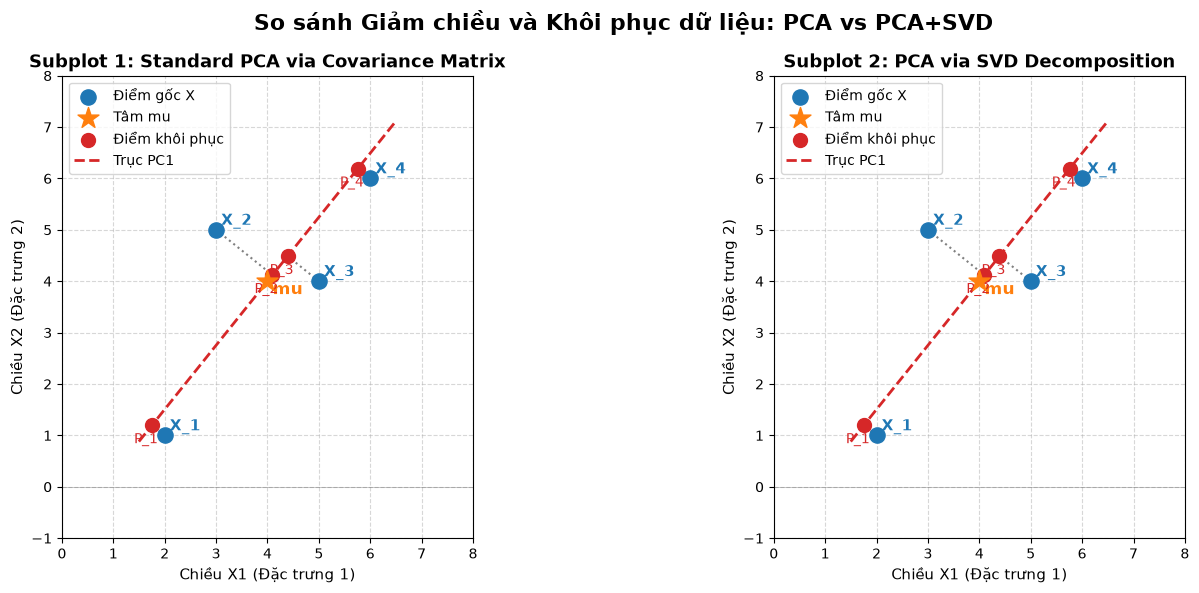

In [34]:
import matplotlib.pyplot as plt

# Tạo hình vẽ gồm 2 subplots nằm ngang
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Tiêu đề chung cho đồ thị
fig.suptitle("So sánh Giảm chiều và Khôi phục dữ liệu: PCA vs PCA+SVD", fontsize=16, fontweight='bold')

# Hàm phụ để vẽ trên từng subplot
def plot_pca_results(ax, X, mu, W, X_rec, title_name):
    # 1. Vẽ các điểm dữ liệu ban đầu
    ax.scatter(X[0, :], X[1, :], color='#1f77b4', s=120, zorder=5, label='Điểm gốc X')
    for i in range(X.shape[1]):
        ax.text(X[0, i] + 0.1, X[1, i] + 0.1, f"X_{i+1}", fontsize=11, color='#1f77b4', fontweight='bold')
    
    # 2. Vẽ điểm trung tâm mu
    ax.scatter(mu[0, 0], mu[1, 0], color='#ff7f0e', marker='*', s=250, zorder=6, label='Tâm mu')
    ax.text(mu[0, 0] + 0.1, mu[1, 0] - 0.25, 'mu', fontsize=12, color='#ff7f0e', fontweight='bold')
    
    # 3. Vẽ các điểm khôi phục X_reconstructed
    ax.scatter(X_rec[0, :], X_rec[1, :], color='#d62728', s=100, zorder=5, label='Điểm khôi phục')
    for i in range(X_rec.shape[1]):
        ax.text(X_rec[0, i] - 0.35, X_rec[1, i] - 0.35, f"P_{i+1}", fontsize=10, color='#d62728')
        
    # 4. Vẽ các đường nét đứt biểu thị trục PC1
    # Trục PC1 đi qua mu và song song với W. Ta kéo dài đường thẳng này.
    t_values = np.linspace(-4, 4, 100)
    pc_line = mu + W * t_values
    ax.plot(pc_line[0, :], pc_line[1, :], color='#d62728', linestyle='--', linewidth=2, label='Trục PC1')
    
    # 5. Vẽ đường chiếu vuông góc (đường chấm màu xám) nối các điểm gốc đến điểm chiếu
    for i in range(X.shape[1]):
        ax.plot([X[0, i], X_rec[0, i]], [X[1, i], X_rec[1, i]], color='gray', linestyle=':', linewidth=1.5)
        
    # Thiết lập cấu hình đồ thị
    ax.set_title(title_name, fontsize=13, fontweight='bold')
    ax.set_xlabel("Chiều X1 (Đặc trưng 1)", fontsize=11)
    ax.set_ylabel("Chiều X2 (Đặc trưng 2)", fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.axhline(0, color='black',linewidth=0.5, alpha=0.3)
    ax.axvline(0, color='black',linewidth=0.5, alpha=0.3)
    ax.set_xlim(0, 8)
    ax.set_ylim(-1, 8)
    ax.legend(loc='upper left')
    ax.set_aspect('equal', adjustable='box')

# Vẽ subplot 1: Standard PCA
# Hãy chuẩn hóa chiều W_pca để biểu thị đúng hướng
W_pca_norm = W_pca / np.linalg.norm(W_pca)
plot_pca_results(axes[0], X, mu, W_pca_norm, X_reconstructed_pca, "Subplot 1: Standard PCA via Covariance Matrix")

# Vẽ subplot 2: PCA+SVD
# SVD có thể tạo hướng ngược lại (đảo dấu vector riêng), ta đảm bảo hướng vẽ đồng bộ để trực quan hóa
W_svd_norm = W_svd / np.linalg.norm(W_svd)
# Nếu hướng của W_svd ngược hướng W_pca, ta đảo dấu để vẽ cùng chiều dễ so sánh
if np.dot(W_pca_norm.T, W_svd_norm) < 0:
    W_svd_norm = -W_svd_norm
plot_pca_results(axes[1], X, mu, W_svd_norm, X_reconstructed_svd, "Subplot 2: PCA via SVD Decomposition")

plt.tight_layout()
plt.show()


### Nhận xét kết quả trực quan hóa PCA & SVD:
- Cả hai phương pháp Standard PCA và PCA+SVD đều cho ra trục chiếu PC1 và kết quả khôi phục dữ liệu giống với nhau.
- Đường nét đứt màu đỏ đi qua tâm dữ liệu $\mu = [4, 4]^T$, định hướng theo chiều có phương sai lớn nhất của dữ liệu gốc.
